In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [120]:
df = pd.read_csv("C:/Users/u461262/OneDrive - WNS/Desktop/Python/Project/classification_data.csv")
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,attrition
0,-1.700306,0.546738,1.697493,1.020916,-3.568689,1.301264,1
1,0.041412,1.157294,0.140774,-3.193412,2.094181,-1.021301,0
2,1.161560,-0.397759,-1.908699,-1.800386,4.323467,-2.244412,1
3,-1.486318,1.104109,-1.306469,-4.843622,3.572225,-2.327224,0
4,1.916012,-1.199254,-2.594574,-0.640792,5.089422,-2.763972,1


In [121]:
df.dtypes

feature_1    float64
feature_2    float64
feature_3    float64
feature_4    float64
feature_5    float64
feature_6    float64
attrition      int64
dtype: object

In [122]:
df.shape

(1000, 7)

In [123]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,attrition
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.017116,0.175382,0.051640,-0.517359,0.540309,-0.512000,0.499000
std,1.556033,0.712990,1.562531,1.317015,2.413842,1.379208,0.500249
min,-4.947865,-2.299349,-4.653281,-4.843622,-7.973939,-4.530188,0.000000
25%,-1.094200,-0.322712,-1.069539,-1.337195,-0.801930,-1.448377,0.000000
50%,0.348773,0.216219,0.080176,-0.665048,0.959777,-0.634875,0.000000
75%,1.128657,0.668742,1.151741,0.278863,2.023553,0.287785,1.000000
max,4.229655,2.258224,5.090814,3.592980,6.224921,3.789293,1.000000


In [124]:
df.isnull().sum()

feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
attrition    0
dtype: int64

In [125]:
df[df.duplicated()]

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,attrition


In [126]:
df['attrition'].value_counts()

attrition
0    501
1    499
Name: count, dtype: int64

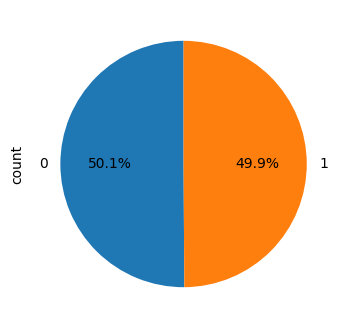

In [127]:
attrition = df['attrition'].value_counts()
plt.figure(figsize = (4,4))
attrition.plot(kind ='pie', autopct = '%1.1f%%', startangle = 90)
plt.show()

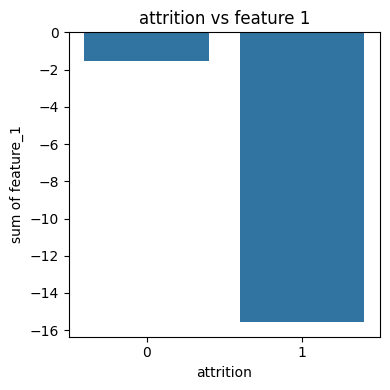

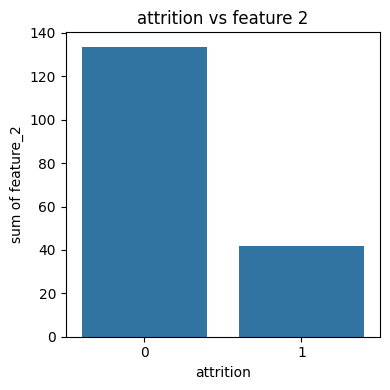

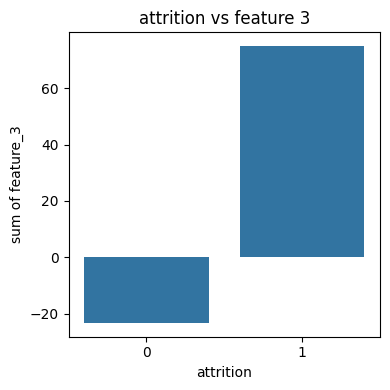

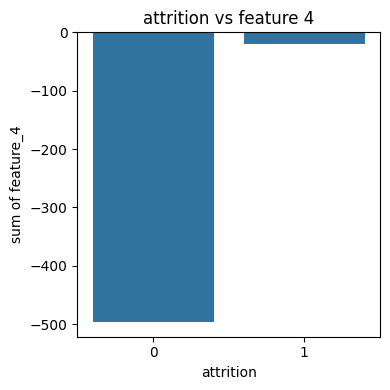

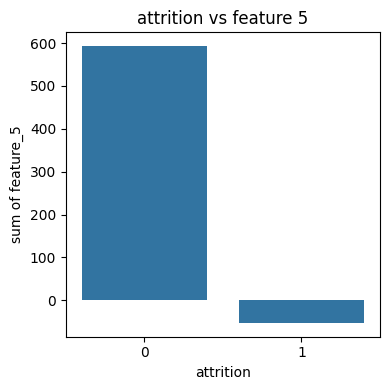

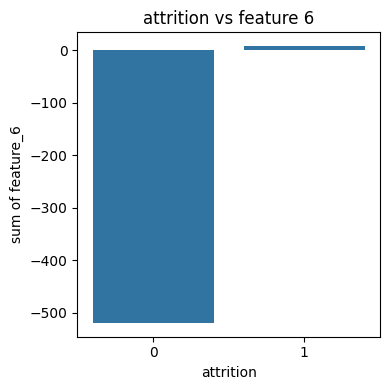

In [128]:
group = df.groupby(df['attrition'])['feature_1'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_1']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_1'], data = group)
plt.title('attrition vs feature 1')
plt.tight_layout()
plt.show()

group = df.groupby(df['attrition'])['feature_2'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_2']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_2'], data = group)
plt.title('attrition vs feature 2')
plt.tight_layout()
plt.show()

group = df.groupby(df['attrition'])['feature_3'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_3']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_3'], data = group)
plt.title('attrition vs feature 3')
plt.tight_layout()
plt.show()

group = df.groupby(df['attrition'])['feature_4'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_4']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_4'], data = group)
plt.title('attrition vs feature 4')
plt.tight_layout()
plt.show()

group = df.groupby(df['attrition'])['feature_5'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_5']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_5'], data = group)
plt.title('attrition vs feature 5')
plt.tight_layout()
plt.show()

group = df.groupby(df['attrition'])['feature_6'].sum().reset_index()
group.columns = ['attrition', 'sum of feature_6']
plt.figure(figsize = (4,4))
sns.barplot(x=group['attrition'], y = group['sum of feature_6'], data = group)
plt.title('attrition vs feature 6')
plt.tight_layout()
plt.show()

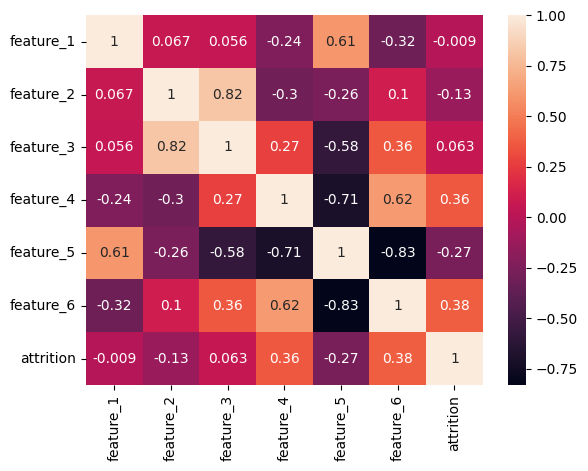

In [129]:
corr = df.corr()
sns.heatmap(corr, annot = True)
plt.show()

In [130]:
print('skewness:', df['attrition'].skew())
print('kurtosis:', df['attrition'].kurt())

skewness: 0.004006019534842479
kurtosis: -2.003995955755041


<Axes: xlabel='feature_1'>

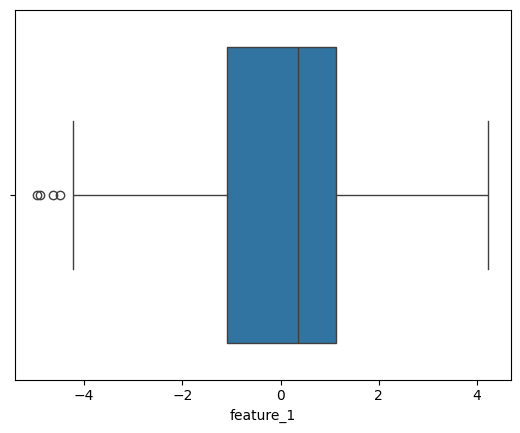

In [131]:
sns.boxplot(x = df['feature_1'])


In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = add_constant(df.drop('attrition', axis = 1))
vif = pd.DataFrame()
vif['features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
print(vif)

    features       VIF
0      const  1.254726
1  feature_1       inf
2  feature_2       inf
3  feature_3       inf
4  feature_4       inf
5  feature_5       inf
6  feature_6       inf


C:\Program Files\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [133]:
from sklearn.model_selection import train_test_split
df.drop('attrition', axis = 1)
y = df['attrition']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = (0.2), random_state=42)


In [134]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 7)
(200, 7)
(800,)
(200,)


In [135]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

para_grid = {
    'C' : [0.1,1,10],
    'penalty' : ['l1', 'l2'],
    'solver' : ['liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), para_grid, cv=5, scoring ='accuracy')
grid.fit(x_train, y_train)
y_pred = grid.predict(x_test)
print('best:', grid.best_params_)
print('accuracy:', accuracy_score(y_test, y_pred))
print('precision:', precision_score(y_test, y_pred))
print('f1 score:', f1_score(y_test, y_pred))
print('recall:', recall_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))
print( classification_report(y_test, y_pred))
      


best: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
accuracy: 0.755
precision: 0.7647058823529411
f1 score: 0.7609756097560976
recall: 0.7572815533980582
[[73 24]
 [25 78]]
              precision    recall  f1-score   support

           0       0.74      0.75      0.75        97
           1       0.76      0.76      0.76       103

    accuracy                           0.76       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.76      0.76      0.76       200



In [136]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

para_grid = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : [3,5,10, None],
    'min_samples_split' : [2,5,10]
}
dt = DecisionTreeClassifier()
grid = GridSearchCV(dt, para_grid, cv=5, scoring ='accuracy')
grid.fit(x_train, y_train)
y_pred = grid.predict(x_test)
print('best:', grid.best_params_)
print('accuracy:', accuracy_score(y_test, y_pred))
print('precision:', precision_score(y_test, y_pred))
print('f1 score:', f1_score(y_test, y_pred))
print('recall:', recall_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))
print( classification_report(y_test, y_pred))

best: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
accuracy: 0.905
precision: 0.9375
f1 score: 0.9045226130653267
recall: 0.8737864077669902
[[91  6]
 [13 90]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91        97
           1       0.94      0.87      0.90       103

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.90       200
weighted avg       0.91      0.91      0.90       200



In [137]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

para_grid = {
    'n_estimators' : [50,100,200],
    'max_depth' : [None, 5,10],
    'min_samples_split' : [2,5],
    'criterion' : ['gini','entropy']
}
rf = RandomForestClassifier()
grid = GridSearchCV(rf, para_grid, cv=5, scoring ='accuracy')
grid.fit(x_train, y_train)
y_pred = grid.predict(x_test)
print('best:', grid.best_params_)
print('accuracy:', accuracy_score(y_test, y_pred))
print('precision:', precision_score(y_test, y_pred))
print('f1 score:', f1_score(y_test, y_pred))
print('recall:', recall_score(y_test, y_pred))
print( confusion_matrix(y_test, y_pred))
print( classification_report(y_test, y_pred))

best: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
accuracy: 0.94
precision: 0.941747572815534
f1 score: 0.941747572815534
recall: 0.941747572815534
[[91  6]
 [ 6 97]]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        97
           1       0.94      0.94      0.94       103

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



In [138]:
df['predicted attrition'] = grid.predict(x)
high_risk_emp = df[df['predicted attrition'] == 1]
print(high_risk_emp)

     feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0    -1.700306   0.546738   1.697493   1.020916  -3.568689   1.301264   
2     1.161560  -0.397759  -1.908699  -1.800386   4.323467  -2.244412   
4     1.916012  -1.199254  -2.594574  -0.640792   5.089422  -2.763972   
8     0.993270   0.309563  -0.114426  -1.256464   1.830397  -0.737353   
9     1.448816   0.121836  -0.474881  -1.211758   2.270669  -0.625872   
..         ...        ...        ...        ...        ...        ...   
991   0.111414   0.193697   0.681608   0.500641  -1.336502   1.126523   
992   0.638737   0.256598  -0.384978  -1.134832   0.846278   0.515750   
996  -1.881668   1.069663   3.365658   1.531590  -4.687709   0.907674   
997   0.525011   0.388696   0.118548  -1.107535   1.208961  -0.609503   
998   0.249114   0.656598   0.716479  -0.724738  -0.736913   1.176324   

     attrition  predicted attrition  
0            1                    1  
2            1                    1  
4        